In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")
import matplotlib.ticker as mtick

Libraries loaded successfully!


In [3]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 541,909
Columns: 8


In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [5]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}).to_string())

             Missing Count  Missing %
InvoiceNo                0       0.00
StockCode                0       0.00
Description           1454       0.27
Quantity                 0       0.00
InvoiceDate              0       0.00
UnitPrice                0       0.00
CustomerID          135080      24.93
Country                  0       0.00


In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

Duplicate rows: 5,268


In [8]:
print(f"Quantity range: {df['Quantity'].min()} to {df['Quantity'].max()}")
print(f"UnitPrice range: {df['UnitPrice'].min()} to {df['UnitPrice'].max()}")
print(f"Sample InvoiceNo values: {df['InvoiceNo'].head().tolist()}")

Quantity range: -80995 to 80995
UnitPrice range: -11062.06 to 38970.0
Sample InvoiceNo values: ['536365', '536365', '536365', '536365', '536365']


In [9]:
df = df.copy()
print("Working copy created.")

Working copy created.


In [10]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Duplicates removed: {before - after:,}")

Rows before: 541,909
Rows after:  536,641
Duplicates removed: 5,268


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

print(f"InvoiceDate type is now: {df['InvoiceDate'].dtype}")
print(f"Sample: {df['InvoiceDate'].iloc[0]}")

InvoiceDate type is now: datetime64[us]
Sample: 2010-12-01 08:26:00


In [12]:
before = df['Description'].isnull().sum()
df['Description'] = df['Description'].fillna('Unknown').str.upper().str.strip()
after = df['Description'].isnull().sum()

print(f"Missing descriptions before: {before:,}")
print(f"Missing descriptions after:  {after:,}")

Missing descriptions before: 1,454
Missing descriptions after:  0


In [13]:
before = len(df)
df = df.dropna(subset=['CustomerID'])
after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows removed: {before - after:,}")

Rows before: 536,641
Rows after:  401,604
Rows removed: 135,037


In [14]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

print(f"CustomerID type: {df['CustomerID'].dtype}")
print(f"Sample values: {df['CustomerID'].head().tolist()}")

CustomerID type: str
Sample values: ['17850', '17850', '17850', '17850', '17850']


In [15]:
before = len(df)

# Remove invoices that start with 'C' (cancellations)
df = df[~df['InvoiceNo'].str.startswith('C')]

# Remove rows where Quantity is zero or negative
df = df[df['Quantity'] > 0]

# Remove rows where UnitPrice is zero or negative
df = df[df['UnitPrice'] > 0]

after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows removed: {before - after:,}")

Rows before: 401,604
Rows after:  392,692
Rows removed: 8,912


In [16]:
df['Country'] = df['Country'].str.strip().str.title()

print("Sample countries:")
print(df['Country'].value_counts().head(10).to_string())

Sample countries:
Country
United Kingdom    349203
Germany             9025
France              8326
Eire                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181


In [17]:
df['Revenue']   = df['Quantity'] * df['UnitPrice']
df['Month']     = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour

print("New columns added. Sample:")
print(df[['InvoiceDate', 'Revenue', 'Month', 'DayOfWeek', 'Hour']].head())

New columns added. Sample:
          InvoiceDate  Revenue    Month  DayOfWeek  Hour
0 2010-12-01 08:26:00    15.30  2010-12  Wednesday     8
1 2010-12-01 08:26:00    20.34  2010-12  Wednesday     8
2 2010-12-01 08:26:00    22.00  2010-12  Wednesday     8
3 2010-12-01 08:26:00    20.34  2010-12  Wednesday     8
4 2010-12-01 08:26:00    20.34  2010-12  Wednesday     8


In [18]:
summary = pd.DataFrame({
    'Issue Found': [
        'Duplicate rows',
        'InvoiceDate stored as text',
        'Missing Description',
        'Missing CustomerID',
        'CustomerID stored as decimal',
        'Cancellation invoices (prefix C)',
        'Negative or zero Quantity',
        'Zero or negative UnitPrice',
        'Inconsistent Country text'
    ],
    'Action Taken': [
        '5,268 duplicates removed',
        'Converted to datetime format',
        '1,454 filled with Unknown',
        '135,037 rows dropped',
        'Converted to whole number then text',
        'Filtered out',
        'Filtered out',
        'Filtered out',
        'Applied strip and title case'
    ]
})

print(summary.to_string(index=False))

                     Issue Found                        Action Taken
                  Duplicate rows            5,268 duplicates removed
      InvoiceDate stored as text        Converted to datetime format
             Missing Description           1,454 filled with Unknown
              Missing CustomerID                135,037 rows dropped
    CustomerID stored as decimal Converted to whole number then text
Cancellation invoices (prefix C)                        Filtered out
       Negative or zero Quantity                        Filtered out
      Zero or negative UnitPrice                        Filtered out
       Inconsistent Country text        Applied strip and title case


In [19]:
df.to_csv('OnlineRetail_cleaned.csv', index=False)
print(f"Saved! Clean dataset has {len(df):,} rows.")

Saved! Clean dataset has 392,692 rows.


In [20]:
print("=== KEY BUSINESS METRICS ===")
print(f"Total Revenue       : £{df['Revenue'].sum():,.2f}")
print(f"Total Transactions  : {df['InvoiceNo'].nunique():,}")
print(f"Total Customers     : {df['CustomerID'].nunique():,}")
print(f"Total Products      : {df['StockCode'].nunique():,}")
print(f"Total Countries     : {df['Country'].nunique():,}")
print(f"Date Range          : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

=== KEY BUSINESS METRICS ===
Total Revenue       : £8,887,208.89
Total Transactions  : 18,532
Total Customers     : 4,338
Total Products      : 3,665
Total Countries     : 37
Date Range          : 2010-12-01 to 2011-12-09


In [21]:
stats = df[['Quantity', 'UnitPrice', 'Revenue']].agg(
    ['mean', 'median', 'min', 'max', 'std']).round(2)

stats.index = ['Mean', 'Median', 'Minimum', 'Maximum', 'Std Dev']
print(stats.to_string())

         Quantity  UnitPrice    Revenue
Mean        13.12       3.13      22.63
Median       6.00       1.95      12.45
Minimum      1.00       0.00       0.00
Maximum  80995.00    8142.75  168469.60
Std Dev    180.49      22.24     311.10


In [22]:
top_products = (df.groupby('Description')['Revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10))

print("Top 10 Products by Revenue:")
print(top_products.to_string())

Top 10 Products by Revenue:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
MANUAL                                 53419.93
RABBIT NIGHT LIGHT                     51251.24


In [23]:
top_countries = (df.groupby('Country')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

print("Top 10 Countries by Revenue:")
print(top_countries.to_string())

Top 10 Countries by Revenue:
Country
United Kingdom    7285024.644
Netherlands        285446.340
Eire               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830


In [24]:
monthly = (df.groupby('Month')['Revenue']
           .sum()
           .sort_index())

print("Monthly Revenue:")
print(monthly.to_string())

Monthly Revenue:
Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440


In [25]:
top_qty = (df.groupby('Description')['Quantity']
           .sum()
           .sort_values(ascending=False)
           .head(10))

print("Top 10 Products by Quantity Sold:")
print(top_qty.to_string())

Top 10 Products by Quantity Sold:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076


In [26]:
customer_stats = (df.groupby('CustomerID').agg(
    Orders     = ('InvoiceNo',  'nunique'),
    TotalSpend = ('Revenue',    'sum'),
    TotalItems = ('Quantity',   'sum')
).sort_values('TotalSpend', ascending=False))

print("Top 10 Customers by Total Spend:")
print(customer_stats.head(10).round(2).to_string())
print()
print("Order Frequency (orders per customer):")
print(customer_stats['Orders'].describe().round(2).to_string())

Top 10 Customers by Total Spend:
            Orders  TotalSpend  TotalItems
CustomerID                                
14646           73   280206.02      196915
18102           60   259657.30       64124
17450           46   194390.79       69973
16446            2   168472.50       80997
14911          201   143711.17       80240
12415           21   124914.53       77374
14156           55   117210.08       57768
17511           31    91062.38       64549
16029           63    80850.84       40108
12346            1    77183.60       74215

Order Frequency (orders per customer):
count    4338.00
mean        4.27
std         7.70
min         1.00
25%         1.00
50%         2.00
75%         5.00
max       209.00


In [27]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110

sns.set_theme(style='whitegrid', palette='Set2')

print("Chart styling ready.")

Chart styling ready.


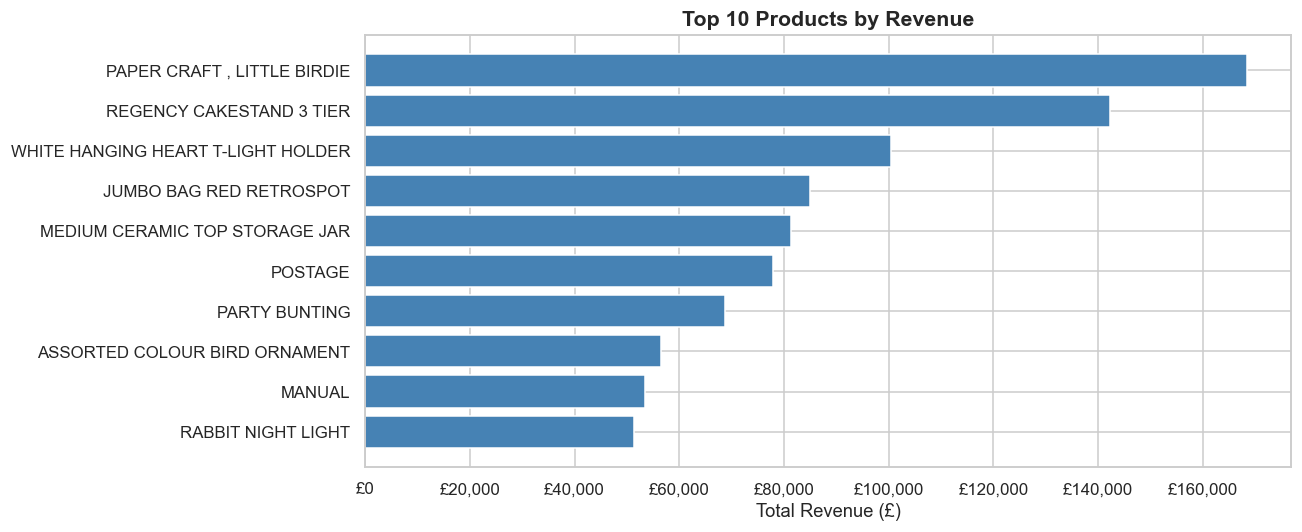

In [30]:
top_rev = (df.groupby('Description')['Revenue']
           .sum()
           .sort_values(ascending=False)
           .head(10))

fig, ax = plt.subplots()

ax.barh(top_rev.index[::-1], top_rev.values[::-1], color='steelblue')

ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig1_top_products.png')
plt.show()

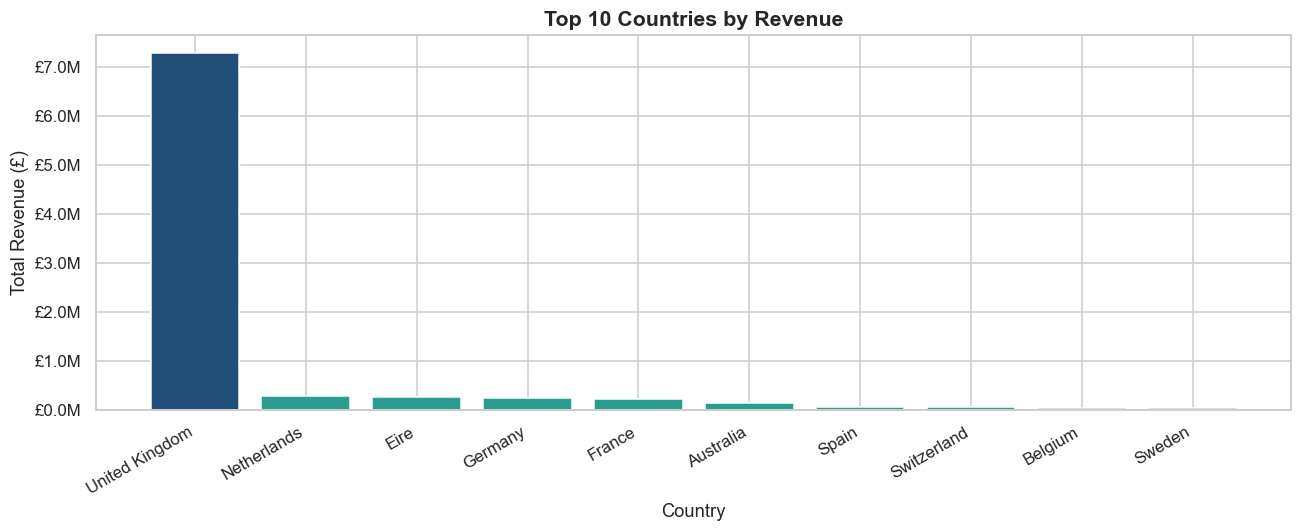

In [31]:
top_c = (df.groupby('Country')['Revenue']
         .sum()
         .sort_values(ascending=False)
         .head(10))

fig, ax = plt.subplots()

colors = ['#1f4e79' if c == 'United Kingdom' else '#2a9d8f' for c in top_c.index]
ax.bar(top_c.index, top_c.values, color=colors, edgecolor='white')

ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig2_top_countries.png')
plt.show()

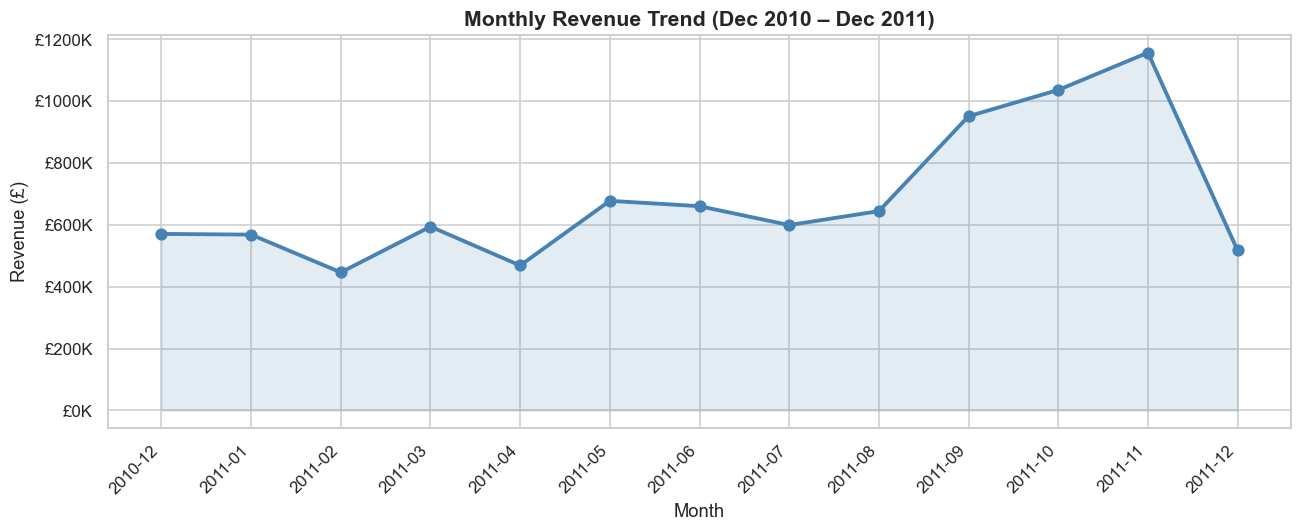

In [32]:
monthly = (df.groupby('Month')['Revenue']
           .sum()
           .sort_index())

fig, ax = plt.subplots()

ax.plot(monthly.index, monthly.values, 
        marker='o', lw=2.5, color='steelblue', ms=7)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')

ax.set_title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig3_monthly_trend.png')
plt.show()

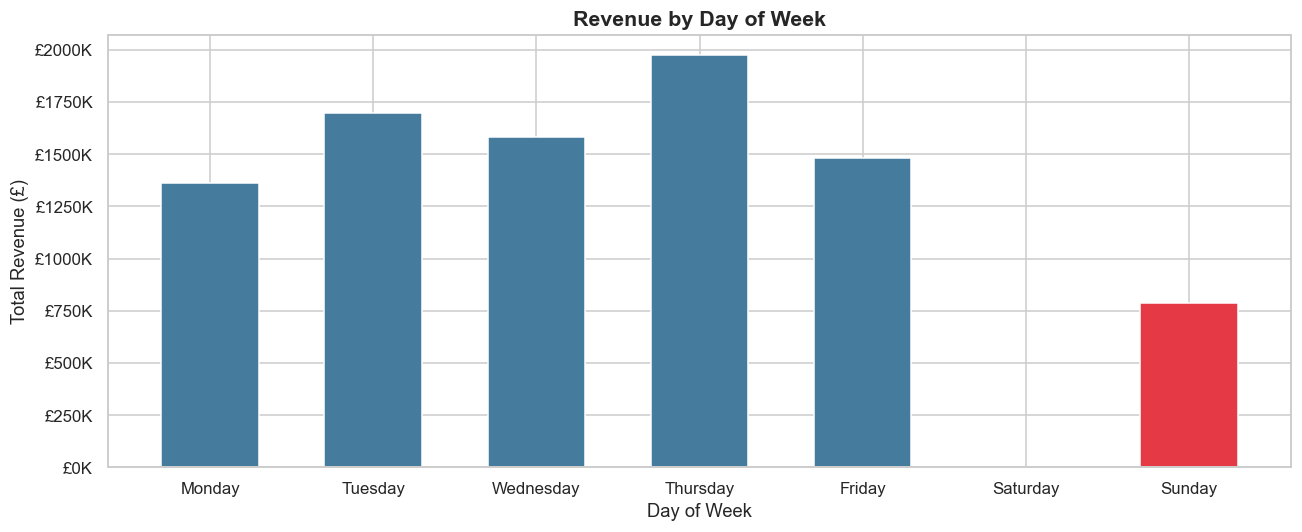

In [33]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (df.groupby('DayOfWeek')['Revenue']
       .sum()
       .reindex(dow_order))

fig, ax = plt.subplots()

colors = ['#e63946' if d in ['Saturday','Sunday'] else '#457b9d' for d in dow.index]
ax.bar(dow.index, dow.values, color=colors, edgecolor='white', width=0.6)

ax.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('fig4_day_of_week.png')
plt.show()

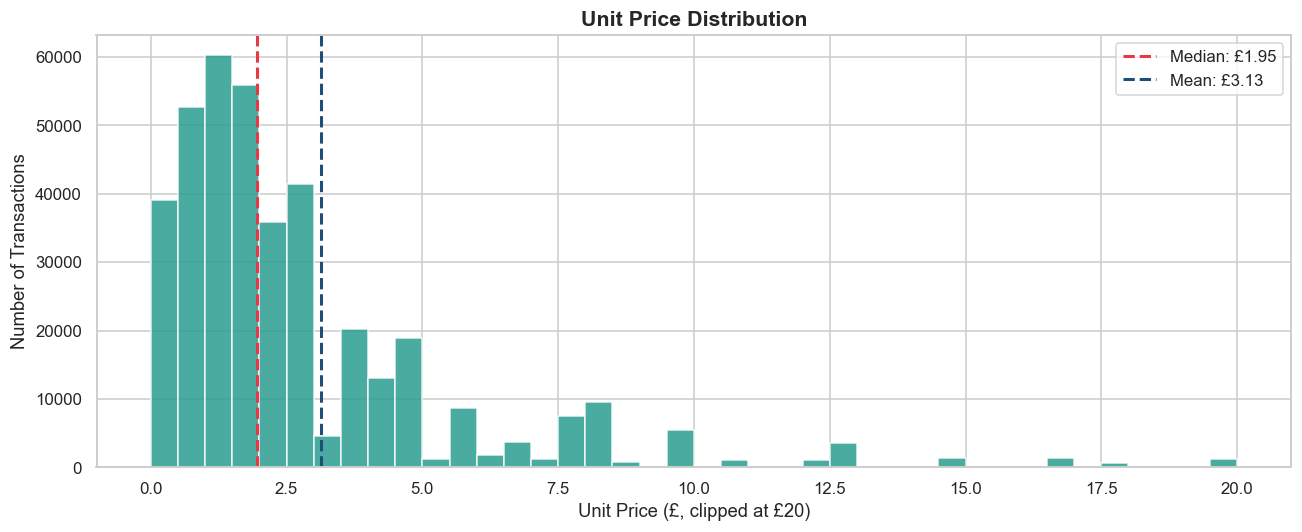

In [34]:
price_clip = df['UnitPrice'].clip(upper=20)

fig, ax = plt.subplots()

ax.hist(price_clip, bins=40, color='#2a9d8f', edgecolor='white', alpha=0.85)
ax.axvline(df['UnitPrice'].median(), color='#e63946', lw=2, ls='--',
           label=f"Median: £{df['UnitPrice'].median():.2f}")
ax.axvline(df['UnitPrice'].mean(), color='#1f4e79', lw=2, ls='--',
           label=f"Mean: £{df['UnitPrice'].mean():.2f}")

ax.set_title('Unit Price Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Unit Price (£, clipped at £20)')
ax.set_ylabel('Number of Transactions')
ax.legend()

plt.tight_layout()
plt.savefig('fig5_price_distribution.png')
plt.show()

# Task 5 — Key Insights

## Insight 1 — The Business is Heavily Dependent on the UK
The United Kingdom generates £7.28 million out of £8.89 million total revenue — 
approximately 82% of all sales from a single country. While the domestic market 
is strong, this represents a significant concentration risk. Germany (£285K), 
Netherlands (£285K), and France (£209K) show promising traction and represent 
the clearest international growth opportunities.

## Insight 2 — Revenue Peaks Sharply in Q4
Monthly revenue remains relatively flat between January and August 
(£446K–£677K per month) then surges dramatically in September, October, 
and November — peaking at £1.15 million in November. This seasonal pattern 
is driven by Christmas gift purchasing and is predictable enough to plan 
around. The business should prepare inventory and marketing spend by August 
each year to fully capture this window.

## Insight 3 — A Small Number of Products Drive Most Revenue
PAPER CRAFT LITTLE BIRDIE alone generated £168,469 — the single highest 
revenue product. The top 10 products contribute a disproportionate share 
of total sales. This is a classic Pareto pattern (a few items drive most 
results). Ensuring these key products are never out of stock is critical 
to protecting revenue.

## Insight 4 — The Customer Base is Predominantly B2B
Transactions are almost entirely concentrated on Tuesday to Thursday, 
with near-zero activity on Saturday and very little on Sunday. This 
weekday-only pattern confirms the customer base is predominantly 
wholesale/trade buyers operating on business hours — not individual 
retail consumers. Marketing and customer service should be designed 
around business needs accordingly.

## Insight 5 — Most Products are Low-Cost but a Premium Tail Exists
The median unit price is just £1.95 but the mean is £3.13 — pulled up 
by a small number of premium items. The majority of transactions involve 
cheap items bought in bulk. Introducing product bundles or minimum order 
thresholds could increase the average order value without needing to 
acquire new customers.